In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy import integrate
from Scattering_Simulator import pairwise_method  #as pairwise_method
from gsd import hoomd
from scipy.spatial.transform import Rotation as R


In [61]:
def extract_positions_orientations(filename):
    """
    Extract positions and orientations from each frame of a GSD file.

    Parameters
    ----------
    filename : str
        Path to the GSD trajectory file.

    Returns
    -------
    positions : list of np.ndarray
        List of arrays of shape (N, 3) with particle positions per frame.
    orientations : list of np.ndarray or None
        List of arrays of shape (N, 4) with quaternions per frame,
        or None if not present in the frame.
    """
    traj = hoomd.open(name=filename, mode='r')

    positions = []
    orientations = []

    for frame in traj:
        positions.append(frame.particles.position.copy())

        if hasattr(frame.particles, 'orientation'):
            orientations.append(frame.particles.orientation.copy())
        else:
            orientations.append(None)

    return positions, orientations


def quaternion_to_euler(quat, degrees=True, order='xyz'):
    """
    Convert a quaternion (HOOMD format: [qw, qx, qy, qz]) to Euler angles.

    Parameters:
    - quat: array-like, quaternion [qw, qx, qy, qz]
    - degrees: bool, return angles in degrees if True (default), radians if False
    - order: str, axes sequence for Euler angles ('xyz', 'zyx', etc.)

    Returns:
    - tuple of 3 Euler angles (angle_x, angle_y, angle_z)
    """
    # Convert to scipy format (qx, qy, qz, qw)
    #scipy_quat = [quat[1], quat[2], quat[3], quat[0]]
    scipy_quat = quat
    r = R.from_quat(scipy_quat)
    angles = r.as_euler(order, degrees=degrees)
    return angles

def grid_points_in_sphere(D, spacing):
    """
    Generate a regular 3D grid of points spaced by 'spacing' that fit inside a sphere.

    Parameters
    ----------
    D : float
        Diameter of the sphere.
    spacing : float
        Distance between adjacent grid points.

    Returns
    -------
    points : np.ndarray of shape (M, 3)
        Grid points inside the sphere.
    """
    radius = D / 2.0
    r2 = radius ** 2

    # Create a 3D grid
    coords = np.arange(-radius, radius + spacing, spacing)
    X, Y, Z = np.meshgrid(coords, coords, coords)
    grid = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T

    # Keep only the points inside the sphere
    mask = np.sum(grid**2, axis=1) <= r2
    points = grid[mask]

    return points

def read_DAT_file(name):
    with open(name) as pdbfile:
        q = []
        I = []
        dI = []
        start = 10000
        for i,line in enumerate(pdbfile):
            if 'q(A-1)' in line:
                start = i
            if i > start: 
                splitted_line = [line[0:20], line[23:50], line[50:]]
                q.append(splitted_line[0])
                I.append(splitted_line[1])
                dI.append(splitted_line[2])
        q = np.array([float(i) for i in q])
        I = np.array([float(i) for i in I])
        dI = np.array([float(i) for i in dI])
        data = np.hstack((q.reshape(-1,1), I.reshape(-1,1), dI.reshape(-1,1)))
    return data

In [78]:
file_path = '../Data/Simulations/Bridge 20 Structure Factor/Sample_52_good/Density_0.005_U_0_46.95262_r0_2.25_n_1.0_m_20.89932/DNA_assembly_20250808001029.gsd' #This is the path to the .gsd file 

In [79]:
positions, orientations = extract_positions_orientations(file_path)
print(f"Number of frames: {len(positions)}")
print("First frame position shape:", positions[0].shape)
print("First frame orientation shape:", orientations[0].shape if orientations[0] is not None else "Not available")

Number of frames: 300
First frame position shape: (5000, 3)
First frame orientation shape: (5000, 4)


In [80]:
orientations_euler = []
for i in range(len(orientations)):
    angles = quaternion_to_euler(orientations[i][:, :]) 
    orientations_euler.append(angles)

lattice_coordinates = []
for i in range(len(orientations_euler)):
    lattice_coordinates.append(np.hstack((positions[i][:, :], orientations_euler[i][:, :])))

In [81]:
indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 299]
lattice_coordinates = [lattice_coordinates[i] for i in indices if i < len(lattice_coordinates)]

In [82]:
#Sphere
D = 1            # diameter of the sphere
spacing = 0.03    # spacing between grid points
points = grid_points_in_sphere(D, spacing)
ones = np.array([1]*len(points))
points = np.hstack((points, ones.reshape(-1,1)))

################################## INPUTS ##########################################################################################
histogram_bins = 10000            # Number of bins in the pairwise distribution calculation 
q = np.geomspace(0.00008, 20, 1000)  # SAXS q-range to be calculated
# Where to save the files and plot
####################################################################################################################################

frames = len(lattice_coordinates)
cmap = cm.jet
norm = plt.Normalize(0, frames - 1)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))
for i in range(frames):
    n_samples = 10000000
    simulator = pairwise_method.scattering_simulator(n_samples)
    simulator.sample_building_block(points)
    simulator.sample_lattice_coordinates(lattice_coordinates[i])
    simulator.calculate_structure_coordinates()
    #I_q = simulator.simulate_multiple_scattering_curves_lattice_coords(points, lattice_coordinates[i], histogram_bins, q, save=False).cpu().numpy()
    #I_q = np.mean(I_q, axis=1)
    I_q = simulator.simulate_scattering_curve_fast_lattice(points, lattice_coordinates[i], histogram_bins, q, save=False).cpu().numpy()
    plt.rcParams.update({'font.size': 18})
    q_rescaled = q/260        
    ax.plot(q_rescaled, I_q, color=cmap(norm(i)), linewidth = 3, label = '10m Sample Size')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylabel('Intensity (arb. unit)')
    ax.set_xlabel('q ($\\AA^{-1}$)')
    #plt.legend(fontsize=14)
    data = np.hstack((q_rescaled.reshape(-1,1), I_q.reshape(-1,1)))
    np.save('../Data/Simulations/Bridge 20 SAXS Curves/scattering_curve_' + str(i) + '.npy', data)   
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Frame')
    #plt.savefig(save_dir + '/scattering_curve_plot.png', dpi=600, bbox_inches="tight")
    plt.close()

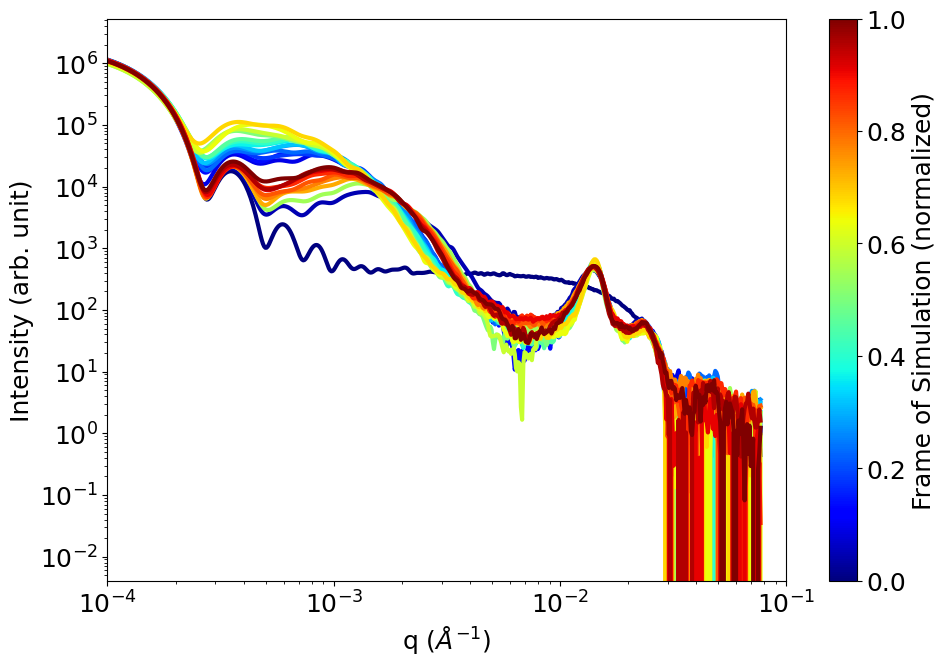

In [91]:
path = '../Data/Simulations/Bridge 20 SAXS Curves/'
filenames = os.listdir(path)

norm = colors.Normalize(vmin=0, vmax=1)
cmap = cm.jet
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
times = np.linspace(0,1, len(indices))

fig, ax = plt.subplots(figsize=(10,7))
for i in range(len(filenames)):
    data = np.load(path + filenames[i])
    ax.plot(data[:,0], data[:,1], linewidth = 3, color=sm.to_rgba(times[i]))
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylabel('Intensity (arb. unit)')
    ax.set_xlabel('q ($\\AA^{-1}$)')
    ax.set_xlim([0.0001, 0.1])

cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
cbar.set_label('Frame of Simulation (normalized)')
plt.tight_layout()


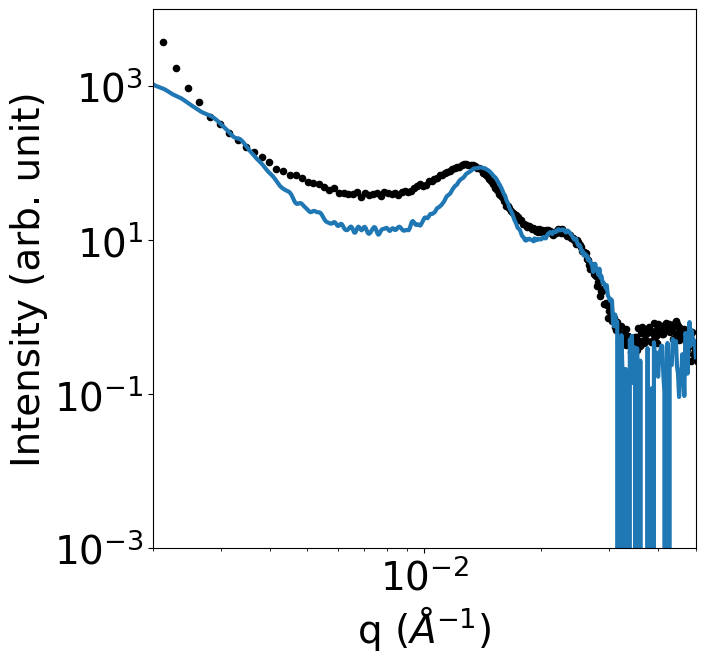

In [77]:
#Load data for bilayer 
path = '../Data/SAXS/Kinetics/ESAXS_Sub/'
filenames = os.listdir(path)
plt.rcParams.update({'font.size': 28})
data0 = read_DAT_file(path + filenames[-1]) 
# Plotting
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(data0[5:,0], data0[5:,1], color='k', s = 20)



path = '../Data/Simulations/Bridge 20 SAXS Curves/'
filenames = os.listdir(path)
data = np.load(path + filenames[1])
ax.plot(data[:,0], data[:,1]*2e-1, linewidth = 3)




#ax.scatter(data1[5:,0], data1[5:,1], color='k', s = 20)
ax.set_xlabel('q ($\\AA$$^{-1}$)')
ax.set_ylabel('Intensity (arb. unit)')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim([0.002, 0.05])
ax.set_ylim([1e-3, 1e4])

#plt.savefig('../Figures/Kinetics_Experiment_0.png', dpi=600, bbox_inches="tight")
plt.show()